In [1]:
import gmsh
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import torch
import torch.nn as nn

In [2]:
# ============================================================
# Problem: -(K p')' = f  on (0,1),  p(0)=p(1)=0
#   K(x)       = 2 + x^2
#   p_exact(x) = sin(2*pi*x)
#   q_exact(x) = -K p' = -(2+x^2)*2*pi*cos(2*pi*x)
#   f(x)       = 4*pi^2*(2+x^2)*sin(2*pi*x) - 4*pi*x*cos(2*pi*x)
# ============================================================

def exact_p_np(x):
    return np.sin(2.0 * np.pi * x)

def exact_q_np(x):
    return -(2.0 + x**2) * 2.0 * np.pi * np.cos(2.0 * np.pi * x)

def forcing_np(x):
    return (
        4.0 * np.pi**2 * (2.0 + x**2) * np.sin(2.0 * np.pi * x)
        - 4.0 * np.pi * x * np.cos(2.0 * np.pi * x)
    )

def forcing_torch(x):
    pi = math.pi
    return (
        4.0 * pi**2 * (2.0 + x**2) * torch.sin(2.0 * pi * x)
        - 4.0 * pi * x * torch.cos(2.0 * pi * x)
    )

In [3]:
# ============================================================
# Mesh generation with gmsh
# ============================================================

def create_mesh_gmsh(N):
    """
    Create a uniform 1D mesh on [0,1] with N elements using gmsh.

    Returns
    -------
    x_vertices  : (N+1,) sorted vertex coordinates
    x_centroids : (N,) cell centroids
    x_left      : (N,) left cell endpoints
    x_right     : (N,) right cell endpoints
    """
    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("darcy_1d")

    lc = 1.0 / N
    gmsh.model.geo.addPoint(0.0, 0.0, 0.0, lc, 1)
    gmsh.model.geo.addPoint(1.0, 0.0, 0.0, lc, 2)
    gmsh.model.geo.addLine(1, 2, 1)
    gmsh.model.geo.synchronize()

    gmsh.model.mesh.setTransfiniteCurve(1, N + 1)
    gmsh.model.mesh.generate(1)

    # All nodes
    node_tags, coords, _ = gmsh.model.mesh.getNodes()
    x_all = coords[0::3]
    tag_to_x = {int(t): x_all[i] for i, t in enumerate(node_tags)}

    # Line elements (type 1 = 2-node line)
    elem_types, _, node_tags_per_elem = gmsh.model.mesh.getElements(dim=1)
    conn = node_tags_per_elem[0].reshape(-1, 2).astype(int)

    x_left  = np.array([tag_to_x[c[0]] for c in conn])
    x_right = np.array([tag_to_x[c[1]] for c in conn])

    # Ensure xL < xR per element
    swap = x_left > x_right
    x_left[swap], x_right[swap] = x_right[swap].copy(), x_left[swap].copy()

    sort_idx   = np.argsort(x_left)
    x_left     = x_left[sort_idx]
    x_right    = x_right[sort_idx]
    x_centroids = 0.5 * (x_left + x_right)
    x_vertices  = np.unique(np.concatenate([x_left, x_right]))

    gmsh.finalize()
    return x_vertices, x_centroids, x_left, x_right


N = 32
x_vertices, x_centroids, x_left, x_right = create_mesh_gmsh(N)

print(f"N cells      = {N}")
print(f"Vertices     = {len(x_vertices)}")
print(f"Centroids    = {len(x_centroids)}")

N cells      = 32
Vertices     = 33
Centroids    = 32


Total collocation points: 65


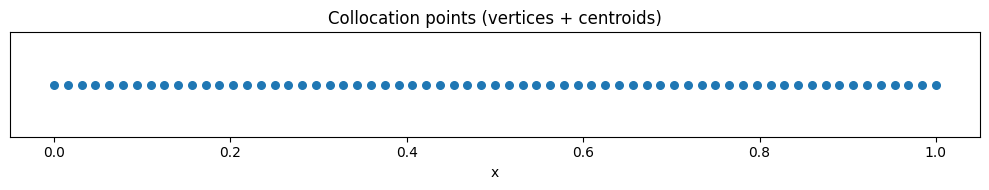

In [4]:
# ============================================================
# Collocation points = vertices union centroids
# ============================================================

x_colloc = np.sort(np.concatenate([x_vertices, x_centroids]))
print(f"Total collocation points: {len(x_colloc)}")

plt.figure(figsize=(10, 2))
plt.scatter(x_colloc, np.zeros_like(x_colloc), s=30, label="collocation pts")
plt.xlabel("x")
plt.yticks([])
plt.title("Collocation points (vertices + centroids)")
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# PINN architecture
# ============================================================

class PressureNet(nn.Module):
    """MLP that predicts pressure p(x)."""

    def __init__(self, width=16, depth=2):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [6]:
# ============================================================
# Training
#
# PDE loss:  mean( (dq/dx - f)^2 )  at collocation points
#            where q = -K(x) * dp/dx
# BC  loss:  p(0)^2 + p(1)^2
# ============================================================

def train_pinn(
    x_colloc,
    lambda_bc=100.0,
    width=16,
    depth=2,
    lr=1e-3,
    epochs=20000,
    print_every=1000,
    seed=1234,
):
    torch.manual_seed(seed)

    x_c   = torch.tensor(x_colloc.reshape(-1, 1), dtype=torch.float64)
    x_bc  = torch.tensor([[0.0], [1.0]], dtype=torch.float64)
    p_bc0 = torch.zeros((2, 1), dtype=torch.float64)

    model = PressureNet(width=width, depth=depth).double()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[7500, 12500, 17500], gamma=0.5
    )

    hist = {"loss": [], "pde": [], "bc": []}

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # -- PDE residual: dq/dx - f = 0  (q = -K dp/dx) --
        x = x_c.clone().requires_grad_(True)
        p = model(x)

        dp_dx = torch.autograd.grad(
            p, x,
            grad_outputs=torch.ones_like(p),
            create_graph=True,
        )[0]

        q = -(2.0 + x**2) * dp_dx

        dq_dx = torch.autograd.grad(
            q, x,
            grad_outputs=torch.ones_like(q),
            create_graph=True,
        )[0]

        loss_pde = torch.mean((dq_dx - forcing_torch(x)) ** 2)

        # -- BC residual --
        loss_bc = torch.mean((model(x_bc) - p_bc0) ** 2)

        loss = loss_pde + lambda_bc * loss_bc
        loss.backward()
        optimizer.step()
        scheduler.step()

        hist["loss"].append(loss.item())
        hist["pde"].append(loss_pde.item())
        hist["bc"].append(loss_bc.item())

        if epoch % print_every == 0:
            print(
                f"[epoch {epoch:6d}] "
                f"loss={loss.item():.4e}  "
                f"pde={loss_pde.item():.4e}  "
                f"bc={loss_bc.item():.4e}"
            )

    for k in hist:
        hist[k] = np.array(hist[k])
    return model, hist


train_start = time.perf_counter()
model, history = train_pinn(
    x_colloc,
    lambda_bc=100.0,
    width=16,
    depth=2,
    lr=1e-3,
    epochs=20000,
    print_every=1000,
    seed=1234,
)
pure_pinn_training_time = time.perf_counter() - train_start
print(f"Pure PINN training time = {pure_pinn_training_time:.6f} s")

[epoch   1000] loss=7.3212e-01  pde=7.3206e-01  bc=6.0763e-07
[epoch   2000] loss=2.4795e-01  pde=2.4787e-01  bc=8.3158e-07
[epoch   3000] loss=1.2488e-01  pde=1.2474e-01  bc=1.3598e-06
[epoch   4000] loss=4.3640e-02  pde=4.3602e-02  bc=3.7990e-07
[epoch   5000] loss=2.3221e-02  pde=2.3215e-02  bc=5.8398e-08
[epoch   6000] loss=1.4224e-02  pde=1.4222e-02  bc=1.9043e-08
[epoch   7000] loss=1.0063e-02  pde=1.0062e-02  bc=5.3581e-09
[epoch   8000] loss=7.8222e-03  pde=7.8220e-03  bc=2.2596e-09
[epoch   9000] loss=6.2138e-03  pde=6.2137e-03  bc=1.1474e-09
[epoch  10000] loss=4.7250e-03  pde=4.7250e-03  bc=4.7260e-10
[epoch  11000] loss=3.4714e-03  pde=3.4714e-03  bc=2.1752e-10
[epoch  12000] loss=2.4997e-03  pde=2.4997e-03  bc=1.3008e-10
[epoch  13000] loss=1.9611e-03  pde=1.9611e-03  bc=1.0450e-10
[epoch  14000] loss=1.6026e-03  pde=1.6026e-03  bc=8.7152e-11
[epoch  15000] loss=1.3041e-03  pde=1.3041e-03  bc=8.9237e-11
[epoch  16000] loss=1.1075e-03  pde=1.1075e-03  bc=2.6659e-10
[epoch  

In [7]:
# ============================================================
# Evaluate p and q = -K dp/dx from the trained PINN
# ============================================================

def eval_p_q(model, x_np):
    """Return (p, q) at numpy array x_np using autograd for q."""
    model.eval()
    x_t = torch.tensor(x_np.reshape(-1, 1), dtype=torch.float64)
    x_t.requires_grad_(True)

    p_t = model(x_t)
    dp_dx = torch.autograd.grad(
        p_t, x_t,
        grad_outputs=torch.ones_like(p_t),
    )[0]

    q_t = -(2.0 + x_t**2) * dp_dx

    return p_t.detach().numpy().flatten(), q_t.detach().numpy().flatten()


# Dense evaluation grid for plotting
x_plot = np.linspace(0.0, 1.0, 500)
p_nn, q_nn = eval_p_q(model, x_plot)
p_ex       = exact_p_np(x_plot)
q_ex       = exact_q_np(x_plot)

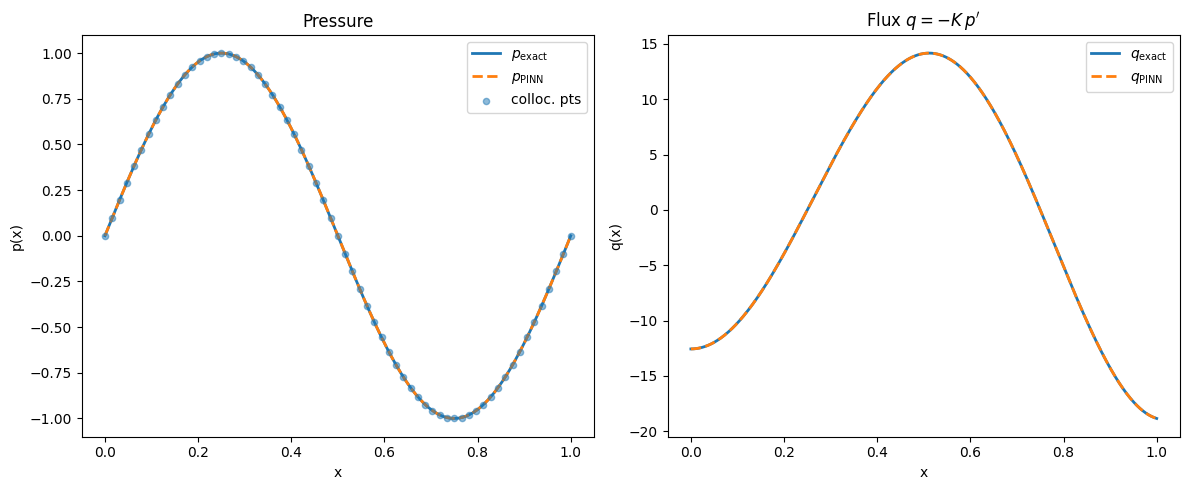

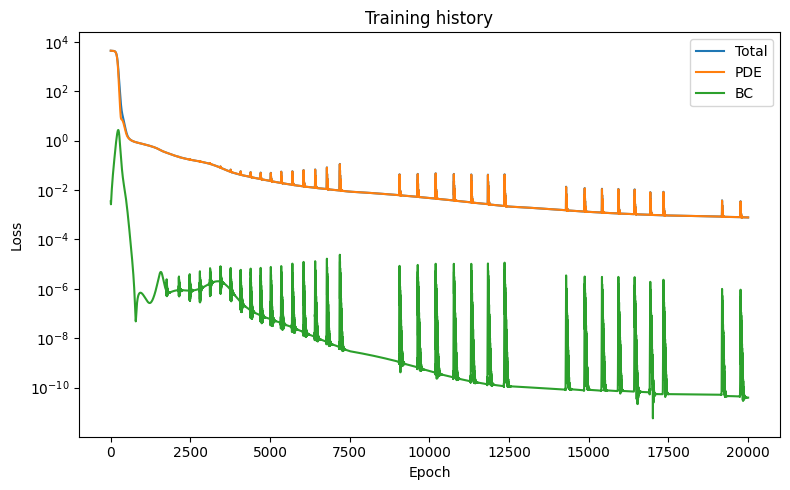

In [8]:
# ============================================================
# Plots: pressure, flux, loss history
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(x_plot, p_ex, label=r"$p_{\mathrm{exact}}$", linewidth=2)
ax.plot(x_plot, p_nn, "--", label=r"$p_{\mathrm{PINN}}$", linewidth=2)
ax.scatter(x_colloc, exact_p_np(x_colloc), s=20, alpha=0.5, zorder=5, label="colloc. pts")
ax.set_xlabel("x")
ax.set_ylabel("p(x)")
ax.set_title("Pressure")
ax.legend()

ax = axes[1]
ax.plot(x_plot, q_ex, label=r"$q_{\mathrm{exact}}$", linewidth=2)
ax.plot(x_plot, q_nn, "--", label=r"$q_{\mathrm{PINN}}$", linewidth=2)
ax.set_xlabel("x")
ax.set_ylabel("q(x)")
ax.set_title(r"Flux $q = -K\,p'$")
ax.legend()

plt.tight_layout()
plt.show()

# Loss history
plt.figure(figsize=(8, 5))
plt.semilogy(history["loss"], label="Total")
plt.semilogy(history["pde"],  label="PDE")
plt.semilogy(history["bc"],   label="BC")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# L2 errors for p and q
# ============================================================

def compute_L2_errors(model, x_left, x_right, nquad=20):
    """
    Gauss-Legendre quadrature on each cell to compute
    ||p_PINN - p_exact||_L2  and  ||q_PINN - q_exact||_L2.
    """
    xi_gl, w_gl = np.polynomial.legendre.leggauss(nquad)
    err_p_sq = 0.0
    err_q_sq = 0.0

    for xL, xR in zip(x_left, x_right):
        h  = xR - xL
        xq = 0.5 * (xR + xL) + 0.5 * h * xi_gl
        wq = 0.5 * h * w_gl

        p_nn_q, q_nn_q = eval_p_q(model, xq)

        err_p_sq += np.sum(wq * (p_nn_q - exact_p_np(xq)) ** 2)
        err_q_sq += np.sum(wq * (q_nn_q - exact_q_np(xq)) ** 2)

    return np.sqrt(err_p_sq), np.sqrt(err_q_sq)


err_p, err_q = compute_L2_errors(model, x_left, x_right)
print(f"||p_PINN - p_exact||_L2 = {err_p:.6e}")
print(f"||q_PINN - q_exact||_L2 = {err_q:.6e}")

||p_PINN - p_exact||_L2 = 6.696551e-06
||q_PINN - q_exact||_L2 = 5.378755e-04


In [10]:
# ============================================================
# Local conservation
#
# For each cell [xL, xR]:
#   R_i = q_PINN(xR) - q_PINN(xL) - \int_{xL}^{xR} f dx
#
# R_i = 0 means local conservation is satisfied exactly.
# ============================================================

def int_f_np(xL_arr, xR_arr, nquad=200):
    """Numerical integral of f over each cell."""
    vals = np.zeros(len(xL_arr))
    for i in range(len(xL_arr)):
        xs = np.linspace(xL_arr[i], xR_arr[i], nquad)
        vals[i] = np.trapz(forcing_np(xs), xs)
    return vals


def compute_local_conservation(model, x_left, x_right):
    """
    Compute cellwise local conservation residuals
        R_i = q_PINN(xR_i) - q_PINN(xL_i) - int_{xL_i}^{xR_i} f dx
    """
    # Evaluate q at left and right endpoints together (avoids double-eval)
    x_bdy = np.concatenate([x_left, x_right])
    _, q_bdy = eval_p_q(model, x_bdy)

    n = len(x_left)
    q_L = q_bdy[:n]
    q_R = q_bdy[n:]

    cell_integrals = int_f_np(x_left, x_right)
    return q_R - q_L - cell_integrals


x_center  = 0.5 * (x_left + x_right)
residuals = compute_local_conservation(model, x_left, x_right)
abs_res   = np.abs(residuals)

print(f"Local conservation summary:")
print(f"  max  |R_i| = {np.max(abs_res):.6e}")
print(f"  mean |R_i| = {np.mean(abs_res):.6e}")
print(f"  min  |R_i| = {np.min(abs_res):.6e}")

Local conservation summary:
  max  |R_i| = 1.497139e-03
  mean |R_i| = 5.844675e-04
  min  |R_i| = 9.450148e-05


/tmp/ipykernel_52910/1476023232.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  vals[i] = np.trapz(forcing_np(xs), xs)


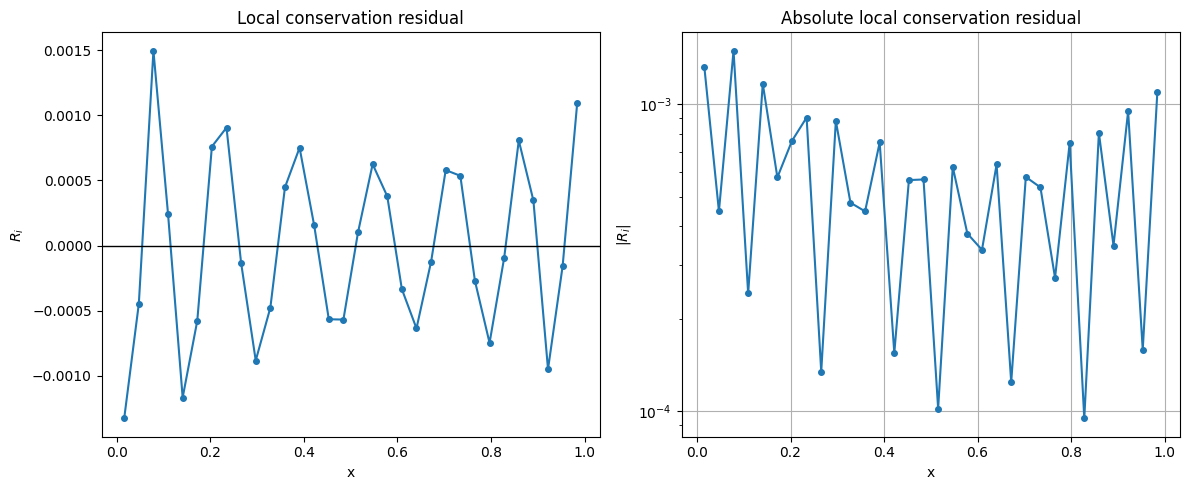

In [11]:
# ============================================================
# Plot local conservation residuals
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(x_center, residuals, "o-", markersize=4)
ax.axhline(0.0, color="k", linewidth=1)
ax.set_xlabel("x")
ax.set_ylabel(r"$R_i$")
ax.set_title("Local conservation residual")

ax = axes[1]
ax.semilogy(x_center, abs_res, "o-", markersize=4)
ax.set_xlabel("x")
ax.set_ylabel(r"$|R_i|$")
ax.set_title("Absolute local conservation residual")
ax.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Summary
# ============================================================

print("=" * 55)
print(f"  Pure PINN — Darcy 1D, K(x)=2+x^2, N={N}")
print("=" * 55)
print(f"  Collocation points : {len(x_colloc)}  ({N+1} vertices + {N} centroids)")
print(f"  Training time      = {pure_pinn_training_time:.6f} s")
print(f"  ||p_PINN - p_exact||_L2 = {err_p:.6e}")
print(f"  ||q_PINN - q_exact||_L2 = {err_q:.6e}")
print(f"  max  |R_i| (local cons.) = {np.max(abs_res):.6e}")
print(f"  mean |R_i| (local cons.) = {np.mean(abs_res):.6e}")
print("=" * 55)

  Pure PINN — Darcy 1D, K(x)=2+x^2, N=32
  Collocation points : 65  (33 vertices + 32 centroids)
  Training time      = 29.323095 s
  ||p_PINN - p_exact||_L2 = 6.696551e-06
  ||q_PINN - q_exact||_L2 = 5.378755e-04
  max  |R_i| (local cons.) = 1.497139e-03
  mean |R_i| (local cons.) = 5.844675e-04


Running pure PINN convergence case with N = 4
[epoch   5000] loss=1.2643e-12  pde=1.2377e-12  bc=2.6631e-16
[epoch  10000] loss=4.5404e-11  pde=4.4383e-11  bc=1.0212e-14
[epoch  15000] loss=5.0609e-10  pde=4.9418e-10  bc=1.1915e-13
[epoch  20000] loss=5.7185e-07  pde=5.5880e-07  bc=1.3048e-10
Running pure PINN convergence case with N = 8
[epoch   5000] loss=2.0482e-02  pde=2.0260e-02  bc=2.2177e-06
[epoch  10000] loss=1.4334e-03  pde=1.4334e-03  bc=9.0926e-11
[epoch  15000] loss=3.8062e-04  pde=3.8062e-04  bc=3.9124e-12
[epoch  20000] loss=1.7909e-04  pde=1.7909e-04  bc=5.9042e-13
Running pure PINN convergence case with N = 16
[epoch   5000] loss=2.1331e-02  pde=2.1324e-02  bc=7.0961e-08
[epoch  10000] loss=4.0028e-03  pde=4.0028e-03  bc=4.2695e-10
[epoch  15000] loss=1.1384e-03  pde=1.1384e-03  bc=1.4432e-10
[epoch  20000] loss=6.2192e-04  pde=6.2192e-04  bc=1.1173e-11
Running pure PINN convergence case with N = 32
[epoch   5000] loss=2.3221e-02  pde=2.3215e-02  bc=5.8398e-08
[epoch  

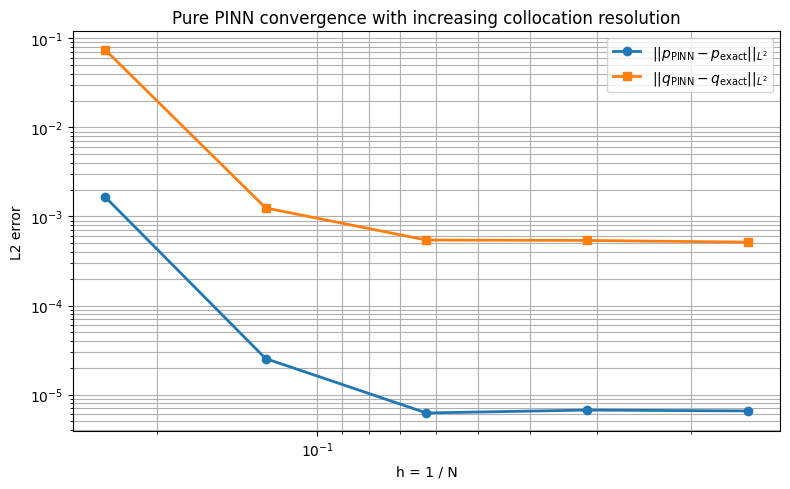

In [13]:
# ============================================================
# Convergence study for the pure PINN
# ============================================================

def convergence_rates(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        rates.append(np.log(errors[i - 1] / errors[i]) / np.log(hs[i - 1] / hs[i]))
    return rates


N_values = [4, 8, 16, 32, 64]
convergence_results = []

for N_case in N_values:
    print("=" * 70)
    print(f"Running pure PINN convergence case with N = {N_case}")
    print("=" * 70)

    x_vertices_case, x_centroids_case, x_left_case, x_right_case = create_mesh_gmsh(N_case)
    x_colloc_case = np.sort(np.concatenate([x_vertices_case, x_centroids_case]))

    train_start_case = time.perf_counter()
    model_case, history_case = train_pinn(
        x_colloc_case,
        lambda_bc=100.0,
        width=16,
        depth=2,
        lr=1e-3,
        epochs=20000,
        print_every=5000,
        seed=1234,
    )
    training_time_case = time.perf_counter() - train_start_case

    err_p_case, err_q_case = compute_L2_errors(model_case, x_left_case, x_right_case)

    convergence_results.append(
        {
            "N": N_case,
            "h": 1.0 / N_case,
            "collocation_points": len(x_colloc_case),
            "training_time": training_time_case,
            "err_p": err_p_case,
            "err_q": err_q_case,
        }
    )


hs_conv = [item["h"] for item in convergence_results]
err_p_conv = [item["err_p"] for item in convergence_results]
err_q_conv = [item["err_q"] for item in convergence_results]
rate_p_conv = convergence_rates(err_p_conv, hs_conv)
rate_q_conv = convergence_rates(err_q_conv, hs_conv)

print("\n" + "=" * 110)
print("Pure PINN convergence study")
print("=" * 110)
print(
    f"{'N':>6} {'colloc':>10} {'h':>12} {'train(s)':>12} "
    f"{'||e_p||_L2':>16} {'rate(p)':>12} {'||e_q||_L2':>16} {'rate(q)':>12}"
)
print("-" * 110)

for i, item in enumerate(convergence_results):
    rate_p_str = "---" if rate_p_conv[i] is None else f"{rate_p_conv[i]:.6f}"
    rate_q_str = "---" if rate_q_conv[i] is None else f"{rate_q_conv[i]:.6f}"
    print(
        f"{item['N']:6d} {item['collocation_points']:10d} {item['h']:12.6e} {item['training_time']:12.6f} "
        f"{item['err_p']:16.8e} {rate_p_str:>12} {item['err_q']:16.8e} {rate_q_str:>12}"
    )


plt.figure(figsize=(8, 5))
plt.loglog(hs_conv, err_p_conv, 'o-', linewidth=2, label=r'$||p_{\mathrm{PINN}} - p_{\mathrm{exact}}||_{L^2}$')
plt.loglog(hs_conv, err_q_conv, 's-', linewidth=2, label=r'$||q_{\mathrm{PINN}} - q_{\mathrm{exact}}||_{L^2}$')
plt.gca().invert_xaxis()
plt.xlabel('h = 1 / N')
plt.ylabel('L2 error')
plt.title('Pure PINN convergence with increasing collocation resolution')
plt.legend()
plt.grid(True, which='both')
plt.tight_layout()
plt.show()
